<a href="https://colab.research.google.com/github/growth-cct/crime-stat-analysis/blob/main/StatAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
!pip install xlsxwriter


# ファイルのアップロード
uploaded = files.upload()

# アップロードされたファイル名を取得し、読み込む
for file_name in uploaded.keys():
    df = pd.read_excel(file_name)

# データフレームの最初の数行を表示
df.head()


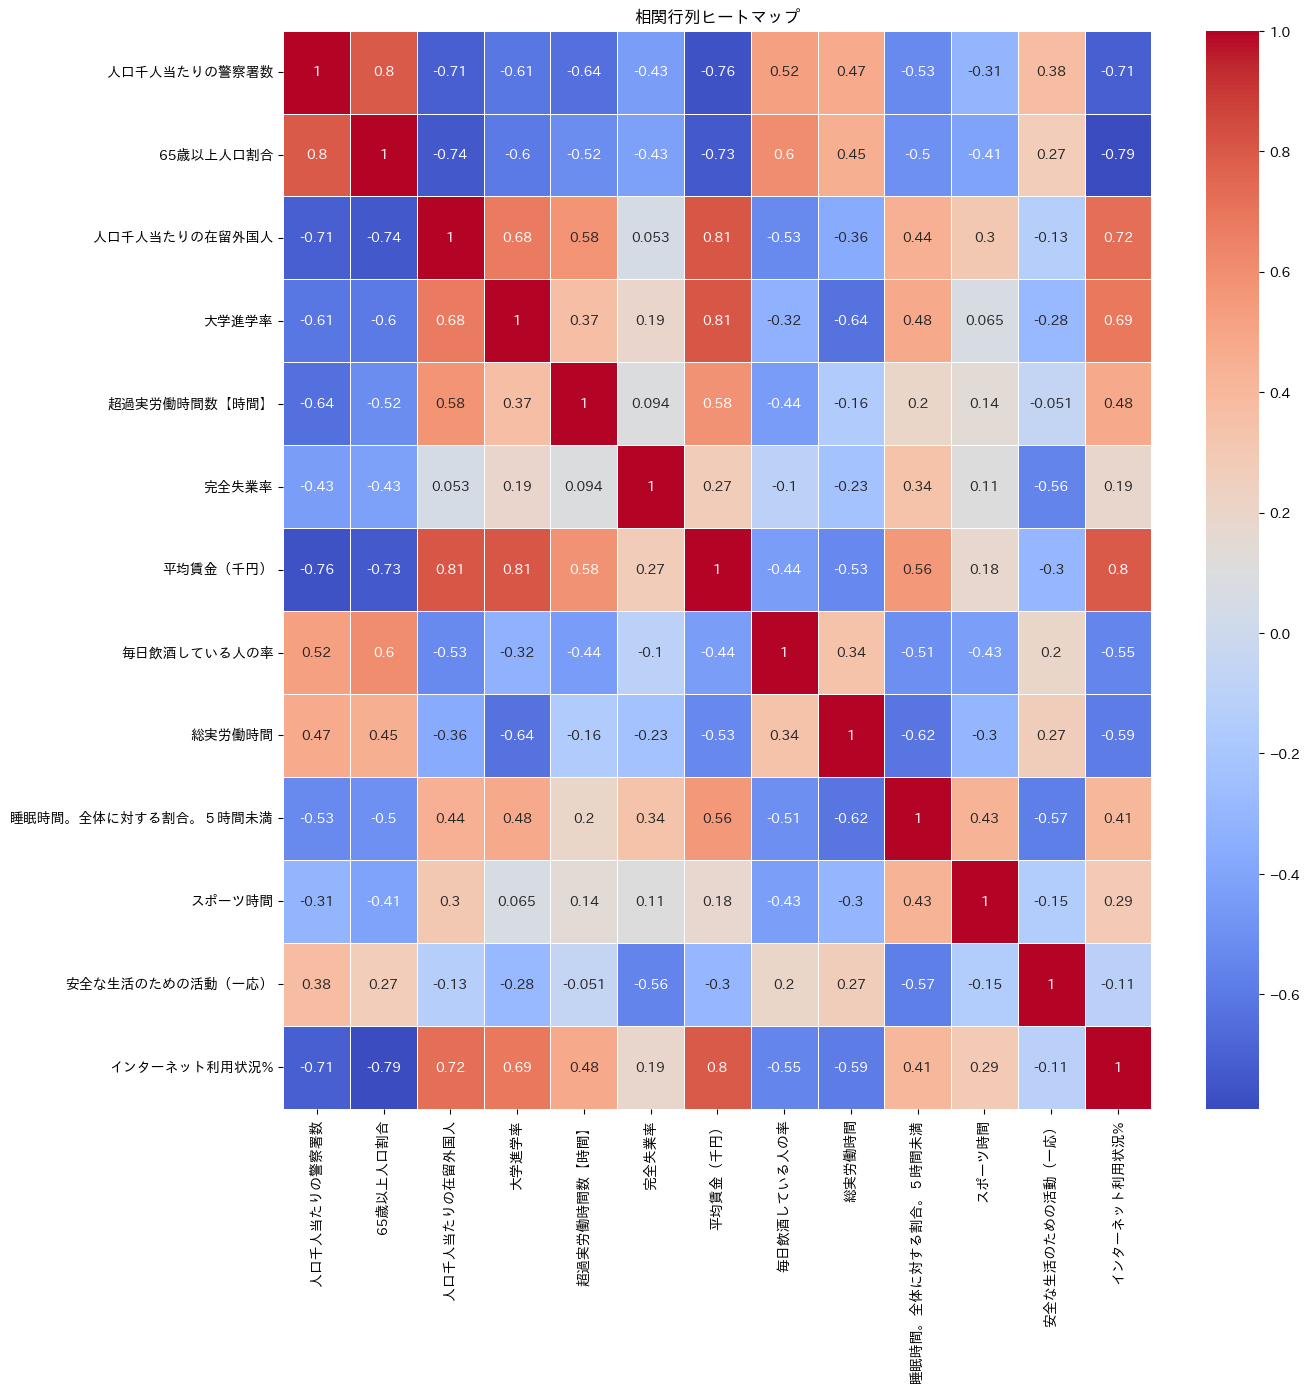

In [ ]:
# Japanize-matplotlib のインストールは必要なので、コメントアウトしておきます
# !pip install japanize-matplotlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib

# 日本語を表示できるように設定
japanize_matplotlib.japanize()

# データの読み込み
df = pd.read_excel('PCA.xlsx')  # ファイル名を適切に設定

# 数値データのみを対象に欠損値を平均値で補完
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# ここで必要に応じて特定の列を除外
# df = df.drop(columns=['認知件数', '総人口/千人'])

# 列名を日本語に変換するコードが必要な場合、適宜追加してください
# column_name_mapping = {'OldName': 'NewNameJapanese'}
# df.rename(columns=column_name_mapping, inplace=True)

# 数値データのみを選択
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# 相関行列の計算
correlation_matrix = numeric_df.corr()

# ヒートマップの作成
plt.figure(figsize=(14, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('相関行列ヒートマップ')
plt.show()

# 相関行列をExcelファイルに保存
correlation_matrix.to_excel('heatmap_correlation_matrix_japanese.xlsx')


In [ ]:
!pip install openpyxl

import openpyxl
from openpyxl.styles import PatternFill

# 相関行列をExcelファイルに保存
correlation_matrix.to_excel('heatmap_correlation_matrix_japanese.xlsx', sheet_name='Correlation')

# Excelファイルを開く
wb = openpyxl.load_workbook('heatmap_correlation_matrix_japanese.xlsx')
ws = wb['Correlation']

# 色を適用するための関数
def apply_color(cell, value):
    if value > 0.5:
        color = 'FF0000'  # 赤色
    elif value < -0.5:
        color = '0000FF'  # 青色
    else:
        color = 'FFFFFF'  # 白色
    cell.fill = PatternFill(start_color=color, end_color=color, fill_type="solid")

# シート内のセルに色を適用
for row in ws.iter_rows(min_row=2, max_col=correlation_matrix.shape[1], max_row=correlation_matrix.shape[0]+1):
    for cell in row:
        if cell.coordinate in ws.merged_cells:  # 結合セルがあればスキップ
            continue
        try:
            value = float(cell.value)
            apply_color(cell, value)
        except (TypeError, ValueError):
            continue

# 変更を保存
wb.save('heatmap_correlation_matrix_japanese_colored.xlsx')
wb.close()


In [ ]:
# 必要なライブラリのインストール
!pip install openpyxl japanize-matplotlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib
from openpyxl import load_workbook
from openpyxl.styles import PatternFill

# データの読み込み
df = pd.read_excel('PCA.xlsx')  # ファイル名を適切に設定

# 数値データのみを対象に欠損値を平均値で補完
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# 不要な列を除外
# df_corr = df.drop(columns=['認知件数', '総人口/千人'])

# 数値データのみを選択し、相関行列の計算
df_corr_numeric = df_corr.select_dtypes(include=['float64', 'int64'])
correlation_matrix = df_corr_numeric.corr()

def apply_color(cell, value):
    # 色を適用する範囲を指定
    if value > 0.5:
        color = 'FF6666'  # 暖色
    elif value < -0.5:
        color = '6666FF'  # 寒色
    else:
        color = 'FFFFFF'  # 中性色
    cell.fill = PatternFill(start_color=color, end_color=color, fill_type="solid")

# シート内のセルに色を適用
for row in ws.iter_rows(min_row=2, max_col=correlation_matrix.shape[1], max_row=correlation_matrix.shape[0]+1):
    for cell in row:
        if cell.coordinate in ws.merged_cells:  # 結合セルがあればスキップ
            continue
        try:
            value = float(cell.value)
            apply_color(cell, value)
        except (TypeError, ValueError):
            continue

# 変更を保存してファイルを閉じる
wb.save('heatmap_correlation_matrix_japanese_colored.xlsx')
wb.close()

# ヒートマップの作成
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('相関行列ヒートマップ')
plt.show()


In [ ]:
# 外れ値欠損補完
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ファイルの読み込み
df = pd.read_excel('PCA.xlsx')  # Google Colaboratoryにアップロードされたファイルを読み込み

# 数値データのみを対象に欠損値を平均値で補完
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# 「一人万人当たりの認知件数」を除外
df_standardize = df.drop(columns=['一人万人当たりの認知件数'])

# 数値データのみを抽出
df_numeric = df_standardize.select_dtypes(include=['float64', 'int64'])

# データの標準化
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

# 標準化されたデータをデータフレームに変換
scaled_df = pd.DataFrame(scaled_data, columns=df_numeric.columns)

# 標準化されたデータをエクセルファイルに保存
scaled_df.to_excel('standardized_data.xlsx', index=False)

# ストレートシート形式で表示
scaled_df


In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import japanize_matplotlib

# 日本語を表示できるように設定
japanize_matplotlib.japanize()

# ファイルの読み込み
df = pd.read_excel('PCA.xlsx')  # Google Colaboratoryにアップロードされたファイルを読み込み

# 数値データのみを対象に欠損値を平均値で補完
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# 「一人万人当たりの認知件数」を除外
# df_pca = df.drop(columns=['人口千人当たりの窃盗認知件数'])

# 数値データのみを抽出
# df_numeric = df_pca.select_dtypes(include=['float64', 'int64'])
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# データの標準化
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

# PCAの実行（第4主成分まで設定）
pca = PCA(n_components=4)
principal_components = pca.fit_transform(scaled_data)

# 主成分を含むデータフレームの作成
pca_df = pd.DataFrame(data=principal_components, columns=['第1主成分', '第2主成分', '第3主成分', '第4主成分'])

# 元のデータから地域名を追加（最初の列が地域名だと仮定）
pca_df['地域'] = df.iloc[:, 0]

# 各成分の寄与率を表示
explained_variance = pca.explained_variance_ratio_
print("主成分の寄与率:", explained_variance)

# 散布図の軸範囲を統一するために、全ての主成分の最小値と最大値を計算
x_min = pca_df[['第1主成分', '第2主成分', '第3主成分', '第4主成分']].min().min()
x_max = pca_df[['第1主成分', '第2主成分', '第3主成分', '第4主成分']].max().max()

# 第1主成分と第2主成分の結果を散布図としてプロット
plt.figure(figsize=(10, 8))
plt.scatter(pca_df['第1主成分'], pca_df['第2主成分'])

# 各点にラベル（地域名）を追加
for i, region in enumerate(pca_df['地域']):
    plt.text(pca_df['第1主成分'][i], pca_df['第2主成分'][i], region)

# グラフのタイトルと軸ラベルを設定
plt.title('主成分分析 (PCA) 結果：第1主成分と第2主成分')
plt.xlabel('第1主成分')
plt.ylabel('第2主成分')

# グラフを表示
plt.grid(True)
plt.show()

# 第3主成分と第4主成分の結果を散布図としてプロット
plt.figure(figsize=(10, 8))
plt.scatter(pca_df['第3主成分'], pca_df['第4主成分'])

# 各点にラベル（地域名）を追加
for i, region in enumerate(pca_df['地域']):
    plt.text(pca_df['第3主成分'][i], pca_df['第4主成分'][i], region)

# グラフのタイトルと軸ラベルを設定
plt.title('主成分分析 (PCA) 結果：第3主成分と第4主成分')
plt.xlabel('第3主成分')
plt.ylabel('第4主成分')

# グラフを表示
plt.grid(True)
plt.show()

# カラム名を確認
print(df.columns)

# カラムが存在するかチェックして削除
if '人口千人当たりの窃盗認知件数' in df.columns:
    df_pca = df.drop(columns=['人口千人当たりの窃盗認知件数'])
else:
    print("カラム '人口千人当たりの窃盗認知件数' はデータフレームに存在しません。")



In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import japanize_matplotlib

# 日本語を表示できるように設定
japanize_matplotlib.japanize()

# ファイルの読み込み
df = pd.read_excel('PCA.xlsx')  # Google Colaboratoryにアップロードされたファイルを読み込み

# 数値データのみを対象に欠損値を平均値で補完
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# 「一人万人当たりの認知件数」を除外
# df_pca = df.drop(columns=['人口千人当たりの窃盗認知件数'])

# 数値データのみを抽出
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# データの標準化
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

# PCAの実行（第4主成分まで設定）
pca = PCA(n_components=4)
principal_components = pca.fit_transform(scaled_data)

# 主成分負荷量（loadings）の計算
loadings = pd.DataFrame(pca.components_.T, columns=['第1主成分', '第2主成分', '第3主成分', '第4主成分'], index=df_numeric.columns)

# 主成分負荷量をストレートテーブル形式で表示
loadings


In [ ]:
# カラム名を確認
print(df.columns)

# カラムが存在するかチェックして削除
if '人口千人当たりの窃盗認知件数' in df.columns:
    df_pca = df.drop(columns=['人口千人当たりの窃盗認知件数'])
else:
    print("カラム '人口千人当たりの窃盗認知件数' はデータフレームに存在しません。")


In [ ]:
!pip install tabulate
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# データの読み込み（例: 'data.xlsx' ファイルからデータを読み込み）
df = pd.read_excel('MRA.xlsx')  # ファイル名を適切に変更してください

# 説明変数（「一万人当たりの窃盗認知件数」を除くすべての変数）
X = df.drop(columns=['人口千人当たりの窃盗認知件数'])  # 必要に応じて他の列も除外

# 目的変数（「一万人当たりの窃盗認知件数」）
y = df['人口千人当たりの窃盗認知件数']

# 説明変数に定数項を加える（切片を含む回帰分析を行うため）
X = sm.add_constant(X)

# 重回帰モデルの作成
model = sm.OLS(y, X)

# モデルのフィッティング
results = model.fit()

# 結果の要約を表示
print(results.summary())

# 回帰係数、p値、決定係数（R^2）を見やすい形で表示
coeff_df = pd.DataFrame({
    '変数': X.columns,
    '回帰係数': results.params,
    'p値': results.pvalues
})

# 決定係数（R^2）
r_squared = results.rsquared

# 出力の整形
print("\n=== 重回帰分析の結果 ===")
print("決定係数（R^2）: {:.3f}".format(r_squared))
print("\n回帰係数とp値:")
print(coeff_df)

# 必要に応じて、データフレームをExcelファイルやCSVに保存
# coeff_df.to_excel('regression_results.xlsx', index=False)  # Excelファイルに保存
# coeff_df.to_csv('regression_results.csv', index=False)  # CSVファイルに保存


In [ ]:
import pandas as pd
import statsmodels.api as sm
from tabulate import tabulate

# データの読み込み（例: 'data.xlsx' ファイルからデータを読み込み）
df = pd.read_excel('MRA.xlsx')  # ファイル名を適切に変更してください

# 説明変数（「一万人当たりの窃盗認知件数」を除くすべての変数）
X = df.drop(columns=['人口千人当たりの窃盗認知件数'])  # 必要に応じて他の列も除外

# 目的変数（「一万人当たりの窃盗認知件数」）
y = df['人口千人当たりの窃盗認知件数']

# 説明変数に定数項を加える（切片を含む回帰分析を行うため）
X = sm.add_constant(X)

# 重回帰モデルの作成
model = sm.OLS(y, X)

# モデルのフィッティング
results = model.fit()

# 全結果の要約を表示
print(results.summary())

# 回帰係数、p値、決定係数（R^2）を見やすい形で表示
coeff_df = pd.DataFrame({
    '変数': X.columns,
    '回帰係数': results.params,
    'p値': results.pvalues
})

# 決定係数（R^2）
r_squared = results.rsquared

# 出力の整形
print("\n=== 重回帰分析の結果 ===")
print("決定係数（R^2）: {:.3f}".format(r_squared))
print("\n回帰係数とp値:")
print(tabulate(coeff_df, headers='keys', tablefmt='psql'))

# 必要に応じて、データフレームをExcelファイルやCSVに保存
# coeff_df.to_excel('regression_results.xlsx', index=False)  # Excelファイルに保存
# coeff_df.to_csv('regression_results.csv', index=False)  # CSVファイルに保存


In [ ]:
import pandas as pd
import statsmodels.api as sm
from tabulate import tabulate

# データの読み込み（例: 'data.xlsx' ファイルからデータを読み込み）
df = pd.read_excel('MRA.xlsx')  # ファイル名を適切に変更してください

# 説明変数（「人口千人当たりの窃盗認知件数」を除くすべての変数）
X = df.drop(columns=['人口千人当たりの窃盗認知件数'])  # 必要に応じて他の列も除外

# 目的変数（「人口千人当たりの窃盗認知件数」）
y = df['人口千人当たりの窃盗認知件数']

# 説明変数に定数項を加える（切片を含む回帰分析を行うため）
X = sm.add_constant(X)

# 重回帰モデルの作成
model = sm.OLS(y, X)

# モデルのフィッティング
results = model.fit()

# 結果のサマリーをデータフレームに変換して整形して表示
summary_df = pd.read_html(results.summary().as_html(), header=0, index_col=0)[0]
print(tabulate(summary_df, headers='keys', tablefmt='psql'))

# 追加統計情報も表示
print("\n=== 追加統計情報 ===")
for i in range(1, len(results.summary().tables)):
    table_html = results.summary().tables[i].as_html()
    table_df = pd.read_html(table_html, header=0, index_col=0)[0]
    print("\n", results.summary().tables[i].title)
    print(tabulate(table_df, headers='keys', tablefmt='psql'))

# 下限値が0よりも大きい場合、または上限値が0よりも小さい場合、その信頼区間は0を含みません。